### **TP5 : Entraînement d’un modèle SVM sur des images (MNIST)**
- Prince Mabengue Junior (22T2832)
- Etonde Mabongo Edouard (22U2163)
- Fonayen Christian Asangwa (23V2370)

#### **PRETRAITEMENT DES DONNEE**

In [11]:
%pip install cvxopt

  Using cached cvxopt-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (43 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 42.7 kB/s eta 0:00:0000:0100:13╸━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/21.3 MB 46.9 kB/s eta 0:04:59
Note: you may need to restart the kernel to use updated packages.


##### Importation des bibliothèques nécessaires

In [19]:
import numpy as np
import pandas as pd
import cvxopt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

#### **Chargement de l’ensemble de données dans mon dataframe (\(df\))**

La structure des données est la suivante : **la première colonne représente les valeurs de \(n\)** comprises dans l’intervalle \([0, 9]\), qui constituent **nos labels**.

In [2]:
train_path = "../Train_test_data/mnist_train.csv"
test_path = "../Train_test_data/mnist_test.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"Données d'entraînement : {df_train.shape}")
print(f"Données de test : {df_test.shape}")

Données d'entraînement : (60000, 785)
Données de test : (10000, 785)


#### **Séparation des données en jeu de test et jeu d’entraînement**

La séparation des données en **jeu d’entraînement** et en **jeu de test** est réalisée en tenant compte du fait que la **première colonne correspond au label**.  

In [3]:
X_train = df_train.iloc[:, 1:].values
y_train = df_train.iloc[:, 0].values
 
X_test = df_test.iloc[:, 1:].values
y_test = df_test.iloc[:, 0].values

# on verifie si la structure est reussite
print(y_train.shape)
print(y_train)

(60000,)
[5 0 4 ... 5 6 8]


#### **Scaling des donnees**
Le **Scaling** (mise à l'échelle) est une étape critique avant d'entraîner un modèle SVM pour trois raisons principales :

1. **Calcul de Distance** : Le SVM cherche à maximiser la "marge" entre les classes en utilisant la **distance euclidienne**. Sans scaling, les pixels ayant de fortes variations de valeurs domineraient injustement le modèle par rapport aux autres.
2. **Vitesse de convergence** : Un dataset normalisé permet à l'algorithme d'optimisation de trouver la solution beaucoup plus rapidement, évitant ainsi des heures de calcul inutiles.

> **Méthode choisie :** Division par **255** pour ramener les pixels dans l'intervalle $[0, 1]$.

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0
# valeur finale a utiliser ( X_train, X_test) -> (y_train, y_test)

#### **Construction du Modele SVM**

##### **Definition du modele SVM**
Nous avons defini notre modèle SVM, ces différents paramètres sont :
- **C** : Le paramètre de régularisation
- **kernel** : Le type de kernel utilisé (linéaire, polynomial, RBF, etc.)
- **gamma** : Le paramètre de kernel pour les kernels non linéaires
- **degree** : Le degré du polynôme pour le kernel polynomial
- **bias** : Le terme de biais pour les kernels polynomial et sigmoid

Et nous avons deinit un mode de classification **one vs. one** pour gérer le problème de classification multi-classes.

In [78]:
class SVM:
    def __init__(self, C=1.0, kernel='linear', gamma='scale', degree=3, bias=1.0):
        self.C = C
        self.kernel = kernel
        self.gamma = gamma
        self.degree = degree
        self.bias = bias
        self.model = None
    
    def _get_kernel_function(self):
        if self.kernel == 'linear':
            return lambda x, y: np.dot(x, y)
        elif self.kernel == 'polynomial':
            return lambda x, y: (np.dot(x, y) + self.bias) ** self.degree
        elif self.kernel == 'sigmoid':
            return lambda x, y: 1 / (1 + np.exp(-self.gamma * np.dot(x, y) + self.bias))
        elif self.kernel == 'tanh':
            return lambda x, y: np.tanh(np.dot(x, y) + self.bias)
        else:
            raise ValueError(f"Incompatible: {self.kernel}")
    
    def _get_gram_matrix(self, X, kernel_function):
        n_samples = X.shape[0]
        gram_matrix = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(n_samples):
                gram_matrix[i, j] = kernel_function(X[i], X[j])
        return gram_matrix
    
    def _solver(self, gram_matrix, y):
        n_samples = len(y)

        P = cvxopt.matrix(np.outer(y, y) * gram_matrix)

        q = cvxopt.matrix(np.ones(n_samples) * -1)
        
        G_upper = np.identity(n_samples)
        G_lower = np.identity(n_samples) * -1
        G = cvxopt.matrix(np.vstack((G_upper, G_lower)))
        
        h_upper = np.ones(n_samples) * self.C
        h_lower = np.zeros(n_samples)
        h = cvxopt.matrix(np.hstack((h_upper, h_lower)))

        A = cvxopt.matrix(y.reshape(1, -1), tc='d')
        b = cvxopt.matrix(0.0)

        cvxopt.solvers.options['show_progress'] = False
        
        # Résolution
        solution = cvxopt.solvers.qp(P, q, G, h, A, b)
        
        return np.ravel(solution['x']) # On applatit
    
    def fit(self, X, y):
        kernel_function = self._get_kernel_function()
        gram_matrix = self._get_gram_matrix(X, kernel_function)
        lamdbas = self._solver(gram_matrix, y)

        # On identifie les vecteurs de support
        support_vector_indices = np.where(lamdbas > 1e-5)[0]
        self.support_vectors_ = X[support_vector_indices]
        self.support_vector_labels_ = y[support_vector_indices]
        self.lamdbas_ = lamdbas[support_vector_indices]

        # Calcul de b
        self.bias_ = np.mean(
            [y_k - np.sum(self.lamdbas_ * self.support_vector_labels_ * kernel_function(self.support_vectors_, self.support_vectors_[i]))
             for i, y_k in enumerate(self.support_vector_labels_)]
        )

    def decision_function(self, X):
        """Retourne le score de décision"""
        kernel_function = self._get_kernel_function()
        decision_values = []
        for x in X:
            decision_value = np.sum(self.lamdbas_ * self.support_vector_labels_ * kernel_function(self.support_vectors_, x)) + self.bias_
            decision_values.append(decision_value)
        return np.array(decision_values)

    def predict(self, X):
        """Prédiction binaire (-1 ou 1)"""
        return np.sign(self.decision_function(X))

class OneVsOneMultiClassSVM:
    """
    Classification multi-classe utilisant l'approche Un-Contre-Un (One-vs-One).
    Pour k classes, crée k*(k-1)/2 classificateurs binaires.
    La prédiction utilise le vote majoritaire.
    """
    def __init__(self, C=1.0, kernel='linear', degree=2, bias=1.0):
        self.C = C
        self.kernel = kernel
        self.degree = degree
        self.bias = bias
        self.classifiers_ = {}  # {(class_i, class_j): SVM}
        self.classes_ = None
    
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        
        print(f"Création de {n_classes * (n_classes - 1) // 2} classificateurs binaires...")
        
        # Créer un SVM pour chaque paire de classes
        for i, class_i in enumerate(self.classes_):
            for class_j in self.classes_[i+1:]:
                print(f"Entraînement SVM pour classes {class_i} vs {class_j}...")
                
                # Sélectionner les échantillons des deux classes
                mask = (y == class_i) | (y == class_j)
                X_subset = X[mask]
                y_subset = y[mask]
                
                # Créer les labels binaires: class_i -> 1, class_j -> -1
                y_binary = np.where(y_subset == class_i, 1, -1)
                
                # Entraîner le SVM
                svm = SVM(C=self.C, kernel=self.kernel, degree=self.degree, bias=self.bias)
                svm.fit(X_subset, y_binary)
                
                # Sauvegarge le classificateur pour ces deux classes
                self.classifiers_[(class_i, class_j)] = svm
    
    def predict(self, X):
        """Prédiction par vote majoritaire"""
        predictions = []
        
        for x in X:
            votes = {c: 0 for c in self.classes_}
            
            # Chaque classificateur vote
            for (class_i, class_j), svm in self.classifiers_.items():
                decision = svm.decision_function(np.array([x]))[0]
                
                # class_i vote si decision > 0, class_j vote si decision < 0
                if decision > 0:
                    votes[class_i] += 1
                else:
                    votes[class_j] += 1
            
            # la classe avec le plus de votes
            predicted_class = max(votes, key=votes.get)
            predictions.append(predicted_class)
        
        return np.array(predictions)


##### **Choix du Kernel**

Le choix du kernel est crucial pour la performance du modèle SVM. Nous avons opté pour le **kernel linéaire** pour verifier la linéarité des données. Cependant, les données ne sont pas linéairement séparables, alors nous avons **polynomial**.

##### **Entraînement du modèle SVM**

In [ ]:
model = OneVsOneMultiClassSVM(kernel='polynomial', degree=2)
sampling = 4000


model.fit(X_train[:sampling], y_train[:sampling])

Création de 45 classificateurs binaires...
Entraînement SVM pour classes 0 vs 1...
Entraînement SVM pour classes 0 vs 2...
Entraînement SVM pour classes 0 vs 3...
Entraînement SVM pour classes 0 vs 4...
Entraînement SVM pour classes 0 vs 5...
Entraînement SVM pour classes 0 vs 6...
Entraînement SVM pour classes 0 vs 7...
Entraînement SVM pour classes 0 vs 8...
Entraînement SVM pour classes 0 vs 9...
Entraînement SVM pour classes 1 vs 2...
Entraînement SVM pour classes 1 vs 3...
Entraînement SVM pour classes 1 vs 4...
Entraînement SVM pour classes 1 vs 5...
Entraînement SVM pour classes 1 vs 6...
Entraînement SVM pour classes 1 vs 7...
Entraînement SVM pour classes 1 vs 8...
Entraînement SVM pour classes 1 vs 9...
Entraînement SVM pour classes 2 vs 3...
Entraînement SVM pour classes 2 vs 4...
Entraînement SVM pour classes 2 vs 5...
Entraînement SVM pour classes 2 vs 6...
Entraînement SVM pour classes 2 vs 7...
Entraînement SVM pour classes 2 vs 8...
Entraînement SVM pour classes 2 vs 9.

In [103]:
y_pred = model.predict(X_test[:sampling])

accuracy = accuracy_score(y_test[:sampling], y_pred)
report = classification_report(y_test[:sampling], y_pred, zero_division=1)

##### **Evaluation de base**

In [104]:
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(report)

Accuracy: 0.9295
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       370
           1       0.94      0.98      0.96       450
           2       0.94      0.93      0.93       418
           3       0.92      0.90      0.91       408
           4       0.92      0.94      0.93       418
           5       0.92      0.93      0.92       372
           6       0.94      0.94      0.94       378
           7       0.92      0.90      0.91       411
           8       0.96      0.89      0.92       384
           9       0.90      0.91      0.91       391

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000



#### **Analyse des resultats**

Ayant les metrique par default, Nous essayons de voir les pourcentages de classification, la confiance des prédictions, la Précision, rappel et F1-score par classe

##### **Matrice de confusion normalisée**

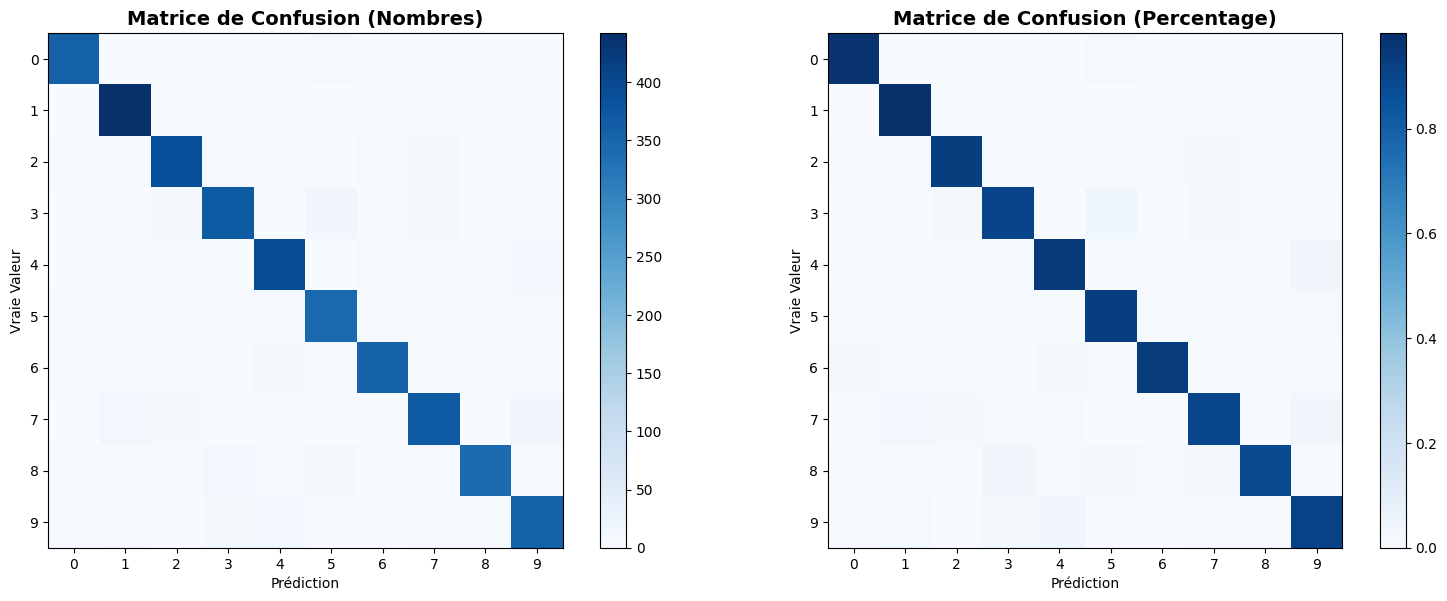

In [105]:
cm = confusion_matrix(y_test[:sampling], y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matrice brute
im1 = axes[0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title('Matrice de Confusion (Nombres)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Prédiction')
axes[0].set_ylabel('Vraie Valeur')
tick_marks = np.arange(10)
axes[0].set_xticks(tick_marks)
axes[0].set_yticks(tick_marks)
plt.colorbar(im1, ax=axes[0])

# Matrice normalisée
im2 = axes[1].imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title('Matrice de Confusion (Percentage)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Prédiction')
axes[1].set_ylabel('Vraie Valeur')
axes[1].set_xticks(tick_marks)
axes[1].set_yticks(tick_marks)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()


La matrice de confusion normalisée nous montre que le model predit avec un bon pourcentage les classes 0, 1, 2, 3, 4, 5, 6, 7, 8 et 9. Cependant, il y a des confusions entre certaines classes, notamment entre les classes 3 et 5, ainsi qu'entre les classes 4 et 9. 

Ces confusions peuvent être dues à la similarité visuelle entre ces chiffres

##### **Précision, Rappel, F1-Score par classe**

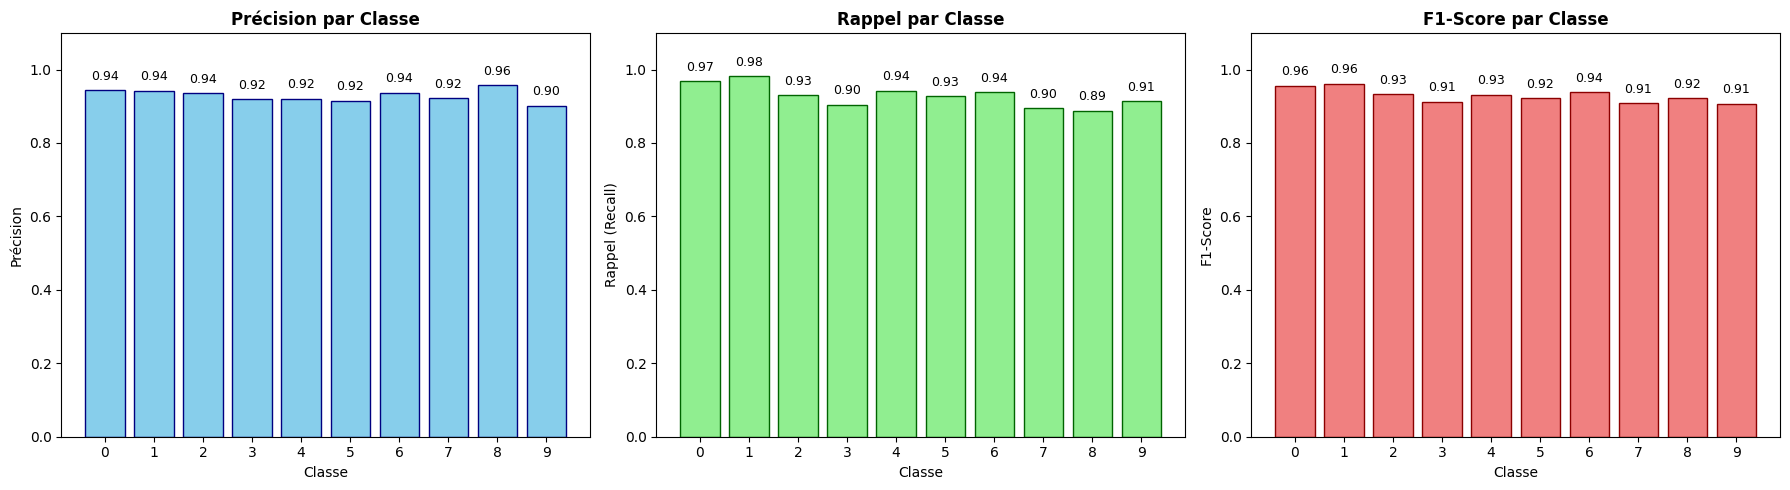

In [106]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test[:sampling], y_pred, average=None
)

classes_range = np.arange(10)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Précision
axes[0].bar(classes_range, precision, color='skyblue', edgecolor='navy')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Précision')
axes[0].set_title('Précision par Classe', fontweight='bold')
axes[0].set_ylim([0, 1.1])
axes[0].set_xticks(classes_range)
for i, v in enumerate(precision):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

# Rappel
axes[1].bar(classes_range, recall, color='lightgreen', edgecolor='darkgreen')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Rappel (Recall)')
axes[1].set_title('Rappel par Classe', fontweight='bold')
axes[1].set_ylim([0, 1.1])
axes[1].set_xticks(classes_range)
for i, v in enumerate(recall):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

# F1-Score
axes[2].bar(classes_range, f1, color='lightcoral', edgecolor='darkred')
axes[2].set_xlabel('Classe')
axes[2].set_ylabel('F1-Score')
axes[2].set_title('F1-Score par Classe', fontweight='bold')
axes[2].set_ylim([0, 1.1])
axes[2].set_xticks(classes_range)
for i, v in enumerate(f1):
    axes[2].text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


On observe que les classes 0, 1, 2, 3, 4, 5, 6, 7, 8 et 9 ont des précisions et rappels relativement élevés, ce qui indique que le modèle est performant pour ces classes. Cependant, les classes 3 et 5 ont des précisions et rappels plus faibles, ce qui suggère que le modèle a du mal à différencier ces classes.